In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import LabelEncoder

In [55]:
df = pd.read_csv("wildfire_model_data.csv")
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (7662, 44)


,fire_id,fire_size,ignition_date,containment_date,duration_days,latitude,longitude,ignition_year,ignition_month,hot_days_6mo,...,grass_fraction,agriculture_fraction,nonburnable_fraction,dominant_veg,avg_vpd_6mo,avg_wind_6mo,extreme_fire_days,avg_precip_6mo,rainy_days_6mo,avg_humidity_6mo
0,10TH_2024_00139,131.961304,2023-06-25 00:00:00,2024-06-25 00:00:00,366,34.971166,-118.109886,2023,6,12.0,...,0.000000,0.000000,0.000000,shrub_fraction,1.305639,4.746389,0.0,0.888333,36.0,70.537315
1,10_2003_07027,212.883774,2002-09-03 00:00:00,2003-09-10 00:00:00,372,40.132079,-124.084808,2002,9,NaN,...,0.569161,0.000000,0.003401,grass_fraction,0.714181,4.684583,0.0,3.983750,50.0,91.340555
2,118_FWY_2015_03742,4.027377,2014-06-04 00:00:00,2015-06-04 00:00:00,365,34.275892,-118.625533,2014,6,NaN,...,0.000000,0.000000,0.000000,shrub_fraction,1.149972,3.034537,0.0,0.889167,21.0,71.191667
3,128_2002_07316,187.959915,2001-09-04 00:00:00,2002-09-05 00:00:00,366,38.507163,-122.091515,2001,9,29.0,...,0.002083,0.000000,0.040278,shrub_fraction,1.603065,3.868611,3.0,0.397593,16.0,80.550648
4,128_2006_06210,57.198334,2005-07-07 00:00:00,2006-07-07 00:00:00,365,38.438790,-122.169162,2005,7,7.0,...,0.000000,0.117063,0.835317,shrub_fraction,0.857130,3.379537,0.0,3.104537,68.0,85.048611


In [56]:
df["log_fire_size"] = np.log1p(df["fire_size"])

In [57]:
drop_cols = ["fire_id", "ignition_date", "containment_date", # metadata, not features
             "fire_size", 
             "duration_days", #   only known after fire is contained — data leakage
             "ignition_year",  # not generalizable to future predictions
             "ignition_month"]  # not generalizable to future predictions
df_model = df.drop(columns=drop_cols)

In [58]:
le = LabelEncoder()
df_model["dominant_veg"] = le.fit_transform(df_model["dominant_veg"].astype(str))

In [59]:
df_model = df_model.dropna()
print(f"Shape after dropping NAs: {df_model.shape}")

Shape after dropping NAs: (4437, 38)


In [60]:
X = df_model.drop(columns=["log_fire_size"])
y = df_model["log_fire_size"]

In [61]:
print(f"Number of features: {X.shape[1]}")
print(f"Feature names: {list(X.columns)}")

Number of features: 37
Feature names: ['latitude', 'longitude', 'hot_days_6mo', 'avg_fm100_6mo', 'avg_fm1000_6mo', 'days_fm100_below_10', 'avg_max_temp_6mo', 'avg_min_temp_6mo', 'hottest_day_6mo', 'coldest_day_6mo', 'avg_daily_temp_range', 'mean_elevation', 'elevation_variability', 'mean_slope', 'open_water', 'barren', 'forest_decid', 'forest_ever', 'forest_mixed', 'shrub', 'grassland', 'pasture', 'crops', 'wetland', 'wetland_herb', 'forest_fraction', 'shrub_fraction', 'grass_fraction', 'agriculture_fraction', 'nonburnable_fraction', 'dominant_veg', 'avg_vpd_6mo', 'avg_wind_6mo', 'extreme_fire_days', 'avg_precip_6mo', 'rainy_days_6mo', 'avg_humidity_6mo']


In [62]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train size: {X_train.shape[0]}")
print(f"Test size: {X_test.shape[0]}")

Train size: 3549
Test size: 888


In [63]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1       
)

rf.fit(X_train, y_train)
print("Model trained!")

Model trained!


In [64]:
y_pred = rf.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"Random Forest R²:  {r2:.4f}")
print(f"Random Forest RMSE: {rmse:.4f}")

Random Forest R²:  0.8327
Random Forest RMSE: 0.8587


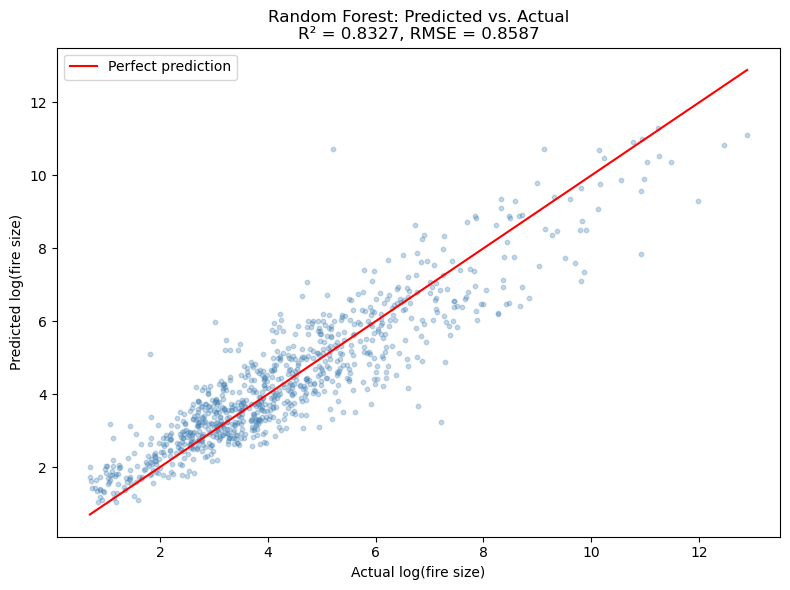

In [65]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.3, s=10, color="steelblue")
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red", linewidth=1.5, label="Perfect prediction"
)
plt.xlabel("Actual log(fire size)")
plt.ylabel("Predicted log(fire size)")
plt.title(f"Random Forest: Predicted vs. Actual\nR² = {r2:.4f}, RMSE = {rmse:.4f}")
plt.legend()
plt.tight_layout()
plt.savefig("predicted_vs_actual.png", dpi=150)
plt.show()

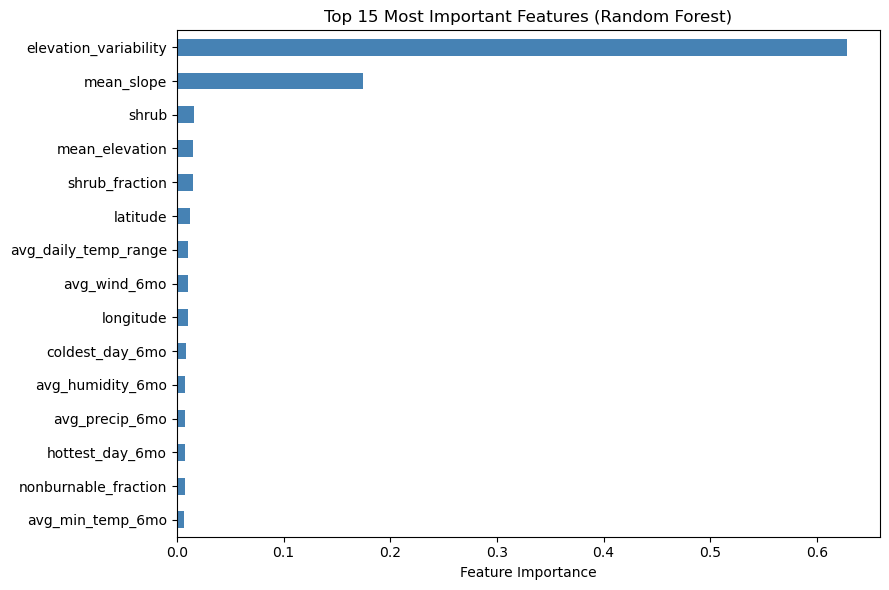

In [66]:
importances = pd.Series(rf.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(9, 6))
importances.sort_values().plot(kind="barh", color="steelblue")
plt.xlabel("Feature Importance")
plt.title("Top 15 Most Important Features (Random Forest)")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150)
plt.show()